In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.insert(1,"../src/")

from utilities import find_peaks, wideband_pulse, MyPolygonSelector
import warping

In [3]:
from visualization_tools import SelectFromCollection

In [4]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import scipy.signal as sp
from scipy.ndimage import label

from matplotlib.widgets import Button

In [5]:
%matplotlib widget

In [6]:
# [Title, Freq, ssp, bdry, pos, beam, cint, rmax] = at.read_env("feif_scenario.env", "KRAKEN")

In [7]:
SAMPLING_FREQ = 2000
TRUE_SOUNDSPEED = 1460

#NPERSEG = 200
WINDOW = sp.windows.hann

NPEAKS = 20

In [8]:
wb_pulse_params = dict(pulse_duration=0.1, fs=SAMPLING_FREQ, bw=200, fc=350, window=sp.windows.hann)

In [9]:
data1 =  scipy.io.loadmat("../data/components_time_series/rts_10km_mca.mat")
x0 = data1['x0'].flatten()
y = data1['y']

In [10]:
replica1 = scipy.io.loadmat("../data/field_values20260707/field_values20260707.mat")

In [11]:
Vg = replica1['Vg'][:,:,replica1['soundspeed'].squeeze() == TRUE_SOUNDSPEED,...].squeeze()
f_vg = replica1['f'][0, 1:-1]
sensor_range = replica1['range'][0,0] * 1e3
t0 = sensor_range/1500

replica_arrival_times = sensor_range/Vg

In [12]:
stft1_short_window = sp.ShortTimeFFT.from_window(
    'hamming', SAMPLING_FREQ, 80, 80-1, mfft = 2000)

stft1_long_window = sp.ShortTimeFFT.from_window(
        'hamming', SAMPLING_FREQ, 200, 200-1, mfft = 2000)

In [13]:
fmask = np.all(np.array([stft1_short_window.f>=200, stft1_short_window.f<=500]), axis=0)

w = stft1_short_window.f[fmask]

In [14]:
t_short = stft1_short_window.t(len(x0)) + t0
t_long = stft1_long_window.t(len(x0)) + t0

In [15]:
t_short

array([6.64716667, 6.64766667, 6.64816667, ..., 7.68516667, 7.68566667,
       7.68616667], shape=(2079,))

## Full Signal

In [16]:
X0_short = stft1_short_window.stft( np.real(x0.squeeze()))[fmask,:]
X0_long = stft1_long_window.stft( np.real(x0.squeeze()))[fmask,:]

In [17]:
peaksx_short = find_peaks(np.abs(X0_short)**2, w, t_short, 17)
peaksx_long = find_peaks(np.abs(X0_long)**2, w, t_long, 17)

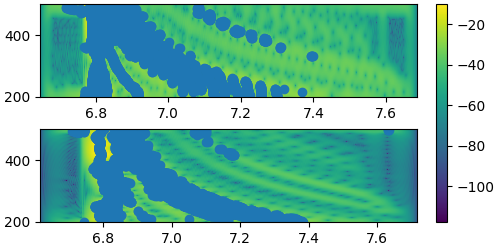

In [18]:
fig, ax = plt.subplots(2,1, layout = 'constrained')

m1 = ax[0].pcolormesh(t_short, w, 10*np.log10(np.abs(X0_short)**2))
ax[0].scatter(peaksx_short[:,0], peaksx_short[:,1])

m1 = ax[1].pcolormesh(t_long, w, 10*np.log10(np.abs(X0_long)**2))
ax[1].scatter(peaksx_long[:,0], peaksx_long[:,1])

fig.colorbar(m1, ax=ax)

fig.set_size_inches([5,2.5])

plt.show()

### Manually sorting the peaks

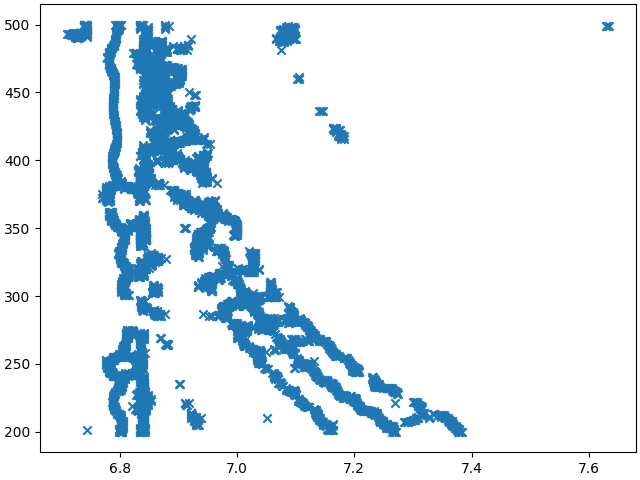

In [19]:
fig, ax = plt.subplots(layout = 'constrained')

points = ax.scatter(peaksx_long[:,0], peaksx_long[:,1], marker = 'x')

In [20]:
selector_long = MyPolygonSelector(ax)

In [21]:
selector_long.select()

In [37]:
selector.disconnect()

classified_peaks.append(selector.xys[selector.ind])

In [35]:
plt.close(fig)

(6.8, 7.5)

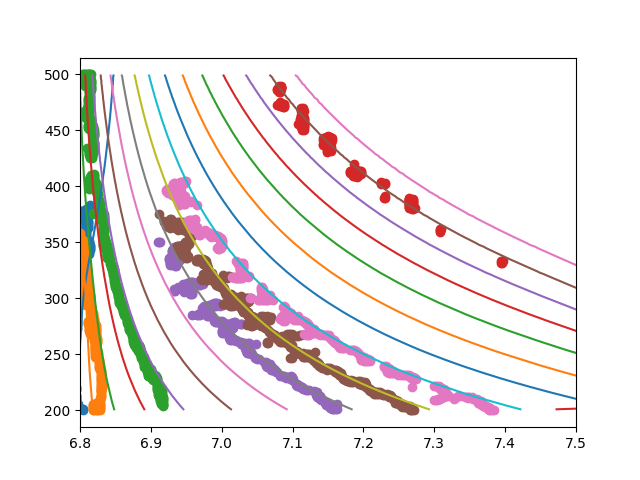

In [38]:
fig, ax = plt.subplots()

ax.plot(sensor_range/Vg.T, f_vg)

for p in classified_peaks:
    ax.scatter(p[:,0], p[:,1])


ax.set_xlim([6.8,7.5])

In [39]:
classified_peaks = np.array([p[:, [1,0]].data for p in classified_peaks], dtype=object)

In [40]:
export = {'peaks_coordinates':classified_peaks, 'mode_nos':np.array([1,2, 5, 16, 8, 9, 10])}


np.savez('../data/output/full_arrival_times.npz', **export)

## Components

### Calculating the spectrograms of the components with both short and long windows
And identifying the peaks of those spectrograms as well.

In [22]:
Y_short = stft1_short_window.stft(np.real(y.mT))[:,fmask,:]
Y_long = stft1_long_window.stft(np.real(y.mT))[:,fmask,:]

In [31]:
peaksy_short = list()

min_peak_height = np.quantile(np.abs(Y_short)**2, 0.9)
for Ynow in Y_short:
    peaksy_short.append(find_peaks(np.abs(Ynow)**2, w, t_short, 10, min_height=min_peak_height))

In [32]:
peaksy_long= list()

min_peak_height = np.quantile(np.abs(Y_long)**2, 0.9)
for Ynow in Y_long:
    peaksy_long.append(find_peaks(np.abs(Ynow)**2, w, t_long, 10, min_height=min_peak_height))

### Plotting the peaks of those spectrograms

(6.666666666666667, 7.666666666666667)

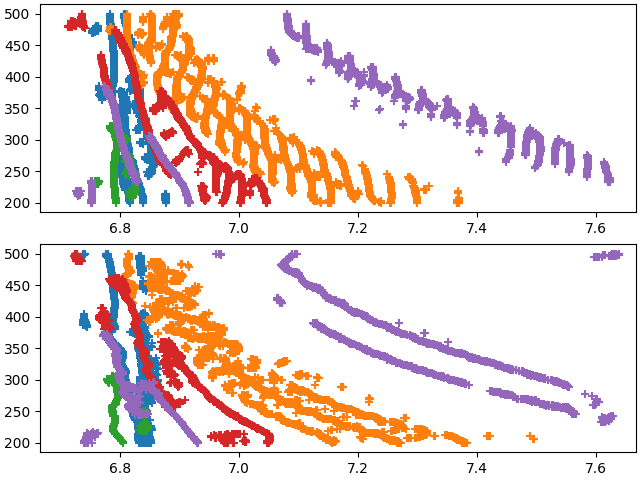

In [34]:
fig, (ax_short, ax_long) = plt.subplots(2,1, layout = 'constrained')

#ax_short.plot(replica_arrival_times.mT, f_vg)

for p in peaksy_short:
    ax_short.scatter(p[:,0], p[:,1], marker = '+', )
ax_short.set_xlim([t0, t0+1])

#ax_long.plot(replica_arrival_times.mT, f_vg)
for p in peaksy_long:
    pts = ax_long.scatter(p[:,0], p[:,1], marker = '+', )
ax_long.set_xlim([t0, t0+1])


### Manually sorting the peaks into mode curves

In [26]:
classified_peaks = list()

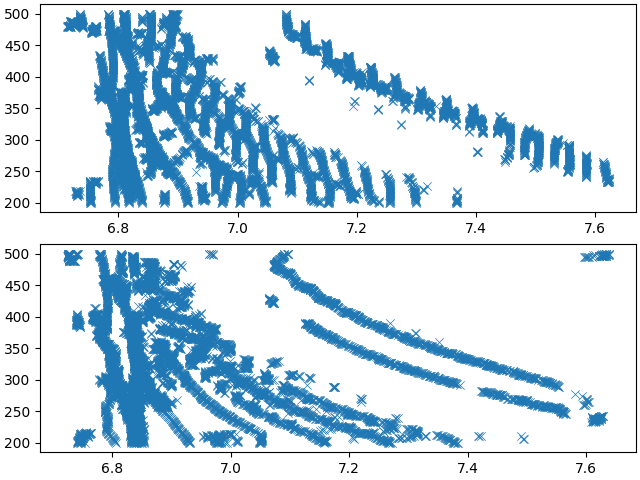

In [86]:
fig, (ax, ax_long) = plt.subplots(2,1,layout = 'constrained')

ax.scatter(np.concatenate(peaksy_short)[:,0], np.concatenate(peaksy_short)[:,1], marker = 'x', linewidths=0.5)
ax_long.scatter(np.concatenate(peaksy_long)[:,0], np.concatenate(peaksy_long)[:,1], marker = 'x', linewidths=0.5)


#ax.set_xlim([6.7, 7.2])


In [87]:
selector_components_short = MyPolygonSelector(ax)

In [90]:
selector_components_short.select()

In [91]:
selector_components_long = MyPolygonSelector(ax_long)

In [97]:
selector_components_long.select()

In [108]:
classified_peaks = list()

nlabels = len(selector_components_short.polygons)
p = np.concatenate(peaksy_short)

for i_label in range(nlabels):
    mask_now = selector_components_short.polygons[i_label].contains_points(p)
    classified_peaks.append(p[mask_now])
    
nlabels = len(selector_components_long.polygons)
p = np.concatenate(peaksy_long)
for i_label in range(nlabels):
    mask_now = selector_components_long.polygons[i_label].contains_points(p)
    classified_peaks.append(p[mask_now])


In [109]:
plt.close('all')

(6.6, 7.5)

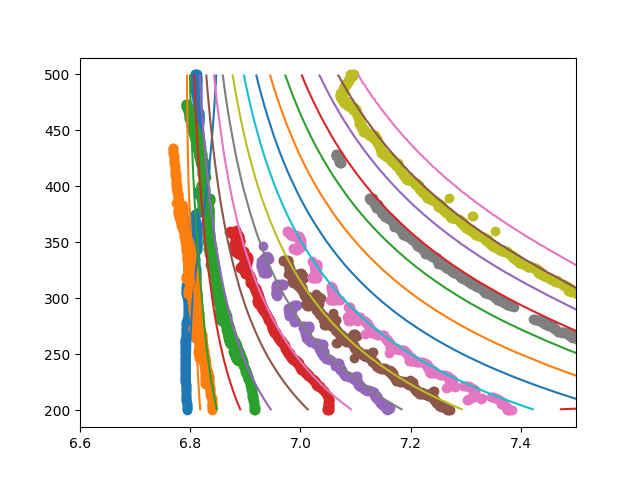

In [110]:
fig, ax = plt.subplots()

ax.plot(sensor_range/Vg.T, f_vg)

for p in classified_peaks:
    ax.scatter(p[:,0], p[:,1])


ax.set_xlim([6.6,7.5])

In [114]:
classified_peaks = np.array([p[:, [1,0]] for p in classified_peaks], dtype=object)

In [115]:
export = {'peaks_coordinates':classified_peaks, 'mode_nos':np.array([1,2,5,7,8,9,10,14,16])}


np.savez('../data/output/components_arrival_times.npz', **export)